In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [5]:
data = pd.read_csv('../data/train/train.csv')
data_test = pd.read_csv('../data/test/test.csv')
print(data.shape)
data.isnull().sum()

(891, 12)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

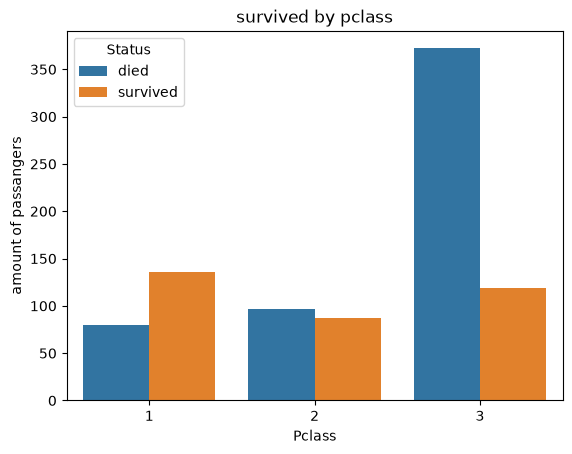

In [56]:
sns.countplot(x='Pclass', hue='Survived', data=data)
plt.title('survived by pclass')
plt.ylabel('amount of passangers')
plt.legend(title='Status', labels=['died', 'survived'])

Text(0.5, 1.0, 'survival by sex')

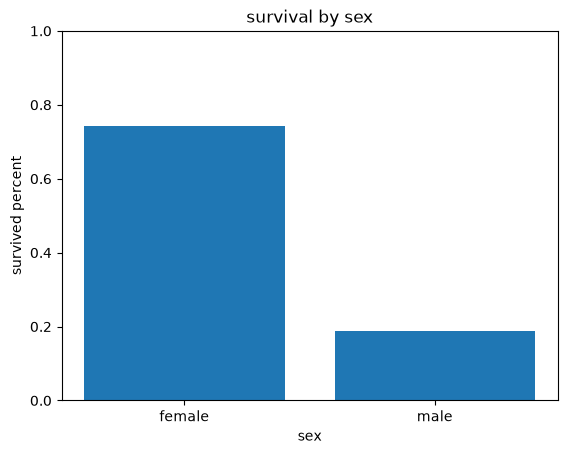

In [58]:

surv = data.groupby('Sex')['Survived'].mean()
plt.bar(surv.index, surv.values)
plt.ylim(0, 1)
plt.xlabel('sex')
plt.ylabel('survived percent')
plt.title('survival by sex')


Text(0, 0.5, 'amount of passangers')

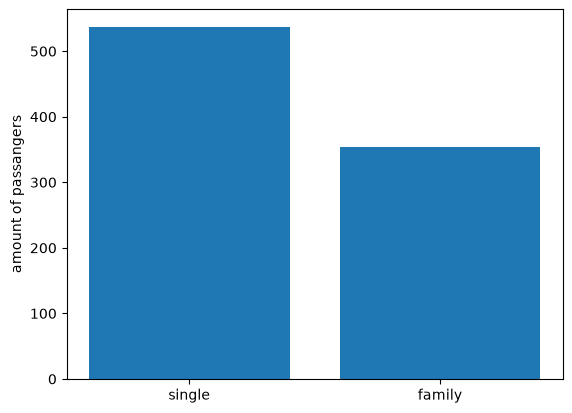

In [60]:
passangers_with_relaives = data[(data['SibSp'] + data['Parch'] > 0)].shape[0]
passangers_singles = data[((data['SibSp'] + data['Parch']) == 0)].shape[0]
plt.bar(x=('single', 'family'), height=(passangers_singles, passangers_with_relaives))
plt.ylabel('amount of passangers')


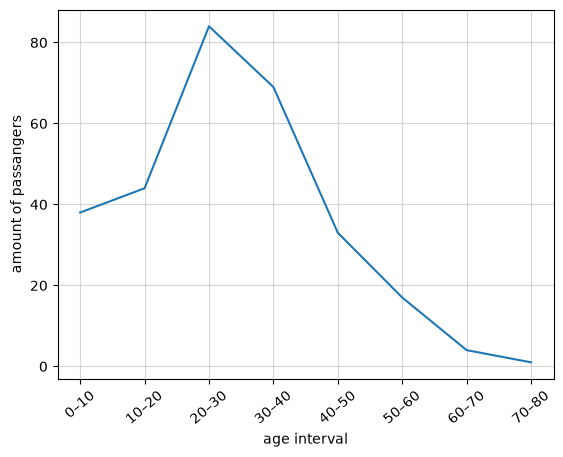

In [62]:
age_labels = [
    "0–10",
    "10–20",
    "20–30",
    "30–40",
    "40–50",
    "50–60",
    "60–70",
    "70–80",
]
age_intervals = pd.cut(data['Age'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80], labels=age_labels)

ave_age_surv = data.groupby(age_intervals)['Survived'].sum()
plt.plot(ave_age_surv.index.astype(str), ave_age_surv.values)
plt.xlabel('age interval')
plt.ylabel('amount of passangers')
plt.grid(alpha=0.5)
plt.xticks(rotation=40)
plt.show()


In [64]:
data.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

CabinKnown
False    0.299854
True     0.666667
Name: Survived, dtype: float64


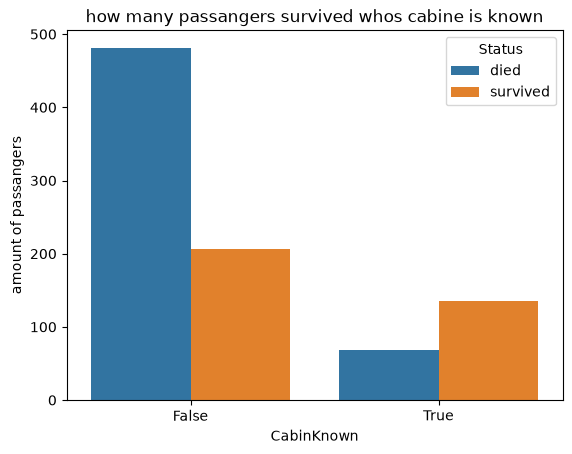

In [68]:
data['CabinKnown'] = data['Cabin'].notna()
sns.countplot(x='CabinKnown', hue='Survived', data=data)
plt.title('how many passangers survived whos cabine is known')
plt.ylabel('amount of passangers')
plt.legend(title='Status', labels=['died', 'survived'])

cabin_survival_rate = data.groupby('CabinKnown')['Survived'].mean()
print(cabin_survival_rate)

In [70]:
print(pd.crosstab(data['Pclass'], data['CabinKnown'], normalize='index'))

print(data.groupby(["Pclass", "CabinKnown"])["Survived"].mean())

CabinKnown     False     True 
Pclass                        
1           0.185185  0.814815
2           0.913043  0.086957
3           0.975560  0.024440
Pclass  CabinKnown
1       False         0.475000
        True          0.664773
2       False         0.440476
        True          0.812500
3       False         0.235908
        True          0.500000
Name: Survived, dtype: float64


## TODO: на валидации поменять данные

In [72]:
data['Age'].median()
data['Age'] = data['Age'].fillna(data['Age'].median())
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
CabinKnown       0
dtype: int64

In [74]:
data['Embarked'].value_counts()
data['Embarked'] = data['Embarked'].fillna('S')
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
CabinKnown       0
dtype: int64

In [79]:
data_test.isna().sum()


PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [80]:
age_median = data["Age"].median()
fare_median = data["Fare"].median()

data_test['CabinKnown'] = data_test['Cabin'].notna()
data_test['Age'] = data_test['Age'].fillna(age_median)
data_test['Fare'] = data_test['Fare'].fillna(fare_median)


In [81]:
data_test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
CabinKnown       0
dtype: int64

In [82]:
print(data.shape)
data_test.shape

(891, 13)


(418, 12)

In [84]:
from sklearn.preprocessing import StandardScaler

data_scaled = data.copy()
data_test_scaled = data_test.copy()

features_to_scale = ['Age', 'Fare', 'SibSp', 'Parch']
scaler = StandardScaler()
data_scaled[features_to_scale] = scaler.fit_transform(
    data[features_to_scale]
)

data_test_scaled[features_to_scale] = scaler.transform(
    data_test[features_to_scale]
)

data_scaled[features_to_scale].describe()

,Age,Fare,SibSp,Parch
count,8.910000e+02,8.910000e+02,8.910000e+02,8.910000e+02
mean,2.272780e-16,3.987333e-18,4.386066e-17,5.382900e-17
std,1.000562e+00,1.000562e+00,1.000562e+00,1.000562e+00
min,-2.224156e+00,-6.484217e-01,-4.745452e-01,-4.736736e-01
25%,-5.657365e-01,-4.891482e-01,-4.745452e-01,-4.736736e-01
50%,-1.046374e-01,-3.573909e-01,-4.745452e-01,-4.736736e-01
75%,4.333115e-01,-2.424635e-02,4.327934e-01,-4.736736e-01
max,3.891554e+00,9.667167e+00,6.784163e+00,6.974147e+00


In [86]:
data.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
CabinKnown       2
dtype: int64

<Axes: >

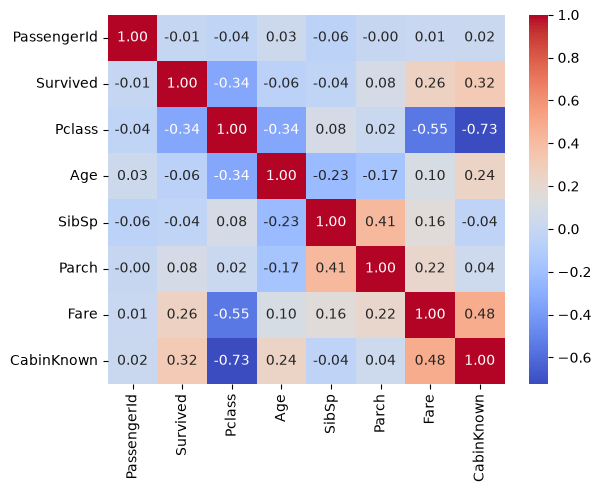

In [88]:
corr_matix = data.corr(numeric_only=True)
sns.heatmap(corr_matix, annot=True, cmap='coolwarm', fmt='.2f')

In [90]:
data_procced_categories = data.copy()
data_procced_categories['CabinKnown'] = data['CabinKnown'].astype('int32')
replace_dict = {'male': 0, 'female': 1}
data_procced_categories['Sex'] = data_procced_categories['Sex'].replace(replace_dict)
data_procced_categories.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinKnown
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,0


In [95]:
# data_procced_categories = pd.get_dummies(data_procced_categories, columns=['Embarked'], drop_first=True, dtype=int)
data_procced_categories

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,CabinKnown,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,1,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,0,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,1,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,28.0,1,2,W./C. 6607,23.4500,NaN,0,0,1
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,1,0,0


#### изучаем выбросы

(array([732., 106.,  31.,   2.,  11.,   6.,   0.,   0.,   0.,   3.]),
 array([  0.     ,  51.23292, 102.46584, 153.69876, 204.93168, 256.1646 ,
        307.39752, 358.63044, 409.86336, 461.09628, 512.3292 ]),
 <BarContainer object of 10 artists>)

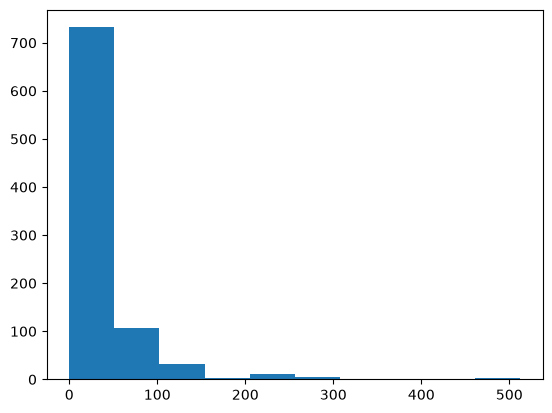

In [96]:
data[['Age', 'Fare']].describe()
plt.hist(data[['Fare']])

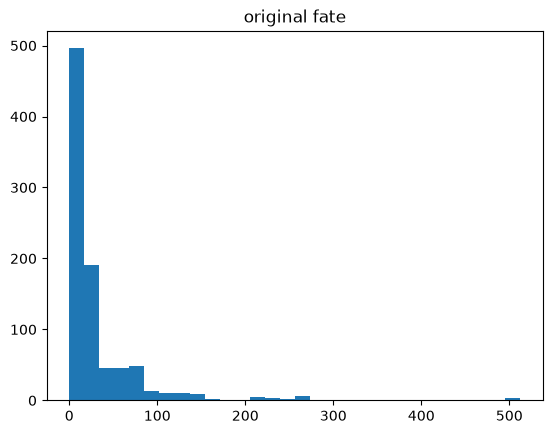

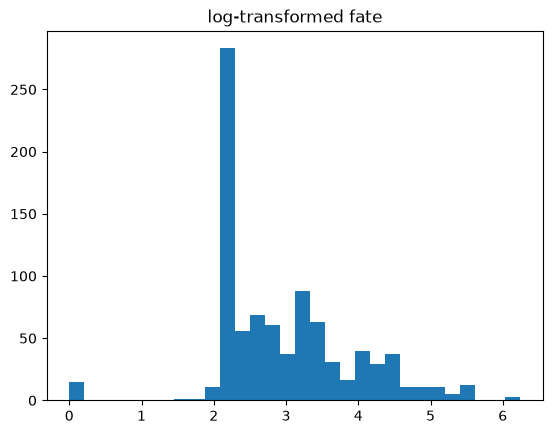

In [98]:
data[data['Fare'] > 400]
data_loged_transformed = data.copy()
data_loged_transformed['FareLog'] = np.log1p(data_loged_transformed['Fare'])

plt.hist(data_loged_transformed['Fare'], bins=30)
plt.title('original fate')
plt.show()

plt.hist(data_loged_transformed[['FareLog']], bins=30)
plt.title('log-transformed fate')
plt.show()

In [99]:
# ticket_group_size = data_loged_transformed.groupby("Ticket")["PassengerId"].transform("count")
# data_loged_transformed['FarePerPerson'] = data_loged_transformed['Fare'] / ticket_group_size

# plt.hist(data_loged_transformed[['FarePerPerson']], bins=30)
# plt.title('Fare per person distribution')
# plt.show()
# data_loged_transformed.loc[
#     data["Fare"] > 400,
#     ["Name", "Ticket", "Fare", "FarePerPerson"]
# ]

### Validation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold

train_X = data_procced_categories.copy()
train_X = train_X.drop(columns=['Survived', 'Name', 'Ticket', 'Cabin', 'PassengerId'])
train_y = data_procced_categories['Survived']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_val_metric = []

for train_indices, val_indices in skf.split(train_X, train_y):
    x_train_fold = train_X.iloc[train_indices]
    x_val_fold = train_X.iloc[val_indices]

    y_train_fold = train_y.iloc[train_indices]
    y_val_fold = train_y.iloc[val_indices]

    model = LogisticRegression(fit_intercept=True, max_iter=1000)

    model.fit(x_train_fold, y_train_fold)

    y_pred = model.predict(x_val_fold)

    accuracy = accuracy_score(y_val_fold, y_pred)
    fold_val_metric.append(accuracy)

print(f"Mean accuracy: {sum(fold_val_metric) / len(fold_val_metric):.4f}")
print(fold_val_metric)
# Mean accuracy: 0.7901 - 5 folds
# Mean accuracy: 0.7968 - 10 folds


Mean accuracy: 0.7901
[0.7821229050279329, 0.8033707865168539, 0.7696629213483146, 0.7640449438202247, 0.8314606741573034]


# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier


from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
jopa = data_procced_categories.copy()
jopa[features_to_scale] = scaler.fit_transform(data[features_to_scale])
train_X = jopa.copy()
train_X = train_X.drop(columns=['Survived', 'Name', 'Ticket', 'Cabin', 'PassengerId'])
train_y = data_procced_categories['Survived']



skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_val_metric = []

for train_indices, val_indices in skf.split(train_X, train_y):
    x_train_fold = train_X.iloc[train_indices]
    x_val_fold = train_X.iloc[val_indices]

    y_train_fold = train_y.iloc[train_indices]
    y_val_fold = train_y.iloc[val_indices]

    knn = KNeighborsClassifier(n_neighbors=14,
                               weights='uniform',
                               metric='manhattan')
    knn.fit(x_train_fold, y_train_fold)

    y_pred = knn.predict(x_val_fold)

    accuracy = accuracy_score(y_val_fold, y_pred)
    fold_val_metric.append(accuracy)

print(f"Mean accuracy: {sum(fold_val_metric) / len(fold_val_metric):.4f}")
print(fold_val_metric)
# Mean accuracy:Mean accuracy: 0.7239 - 5 folds
# Mean accuracy: 0.7968 - 10 folds
# Mean accuracy: 0.7284 -  5 folds - 13 neighbors
# Mean accuracy: 0.7441  - 5 folds - weights='distance - 14 neighbors
# Mean accuracy: 0.7620 - 5 folds - weights= 'distance' - 14 neigbors - metic = manhattan

# 0.8092 - w - distance - m - manhattan - n - 14
# 0.8137 - w - uniform - m - manhattan - n - 14 - scaled data
# 

Mean accuracy: 0.8137
[0.8379888268156425, 0.8202247191011236, 0.7752808988764045, 0.8426966292134831, 0.7921348314606742]


# decision tree

Mean val accuracy: 0.7912
Mean train accuracy: 0.9851
[0.7877094972067039, 0.8539325842696629, 0.7191011235955056, 0.7865168539325843, 0.8089887640449438]


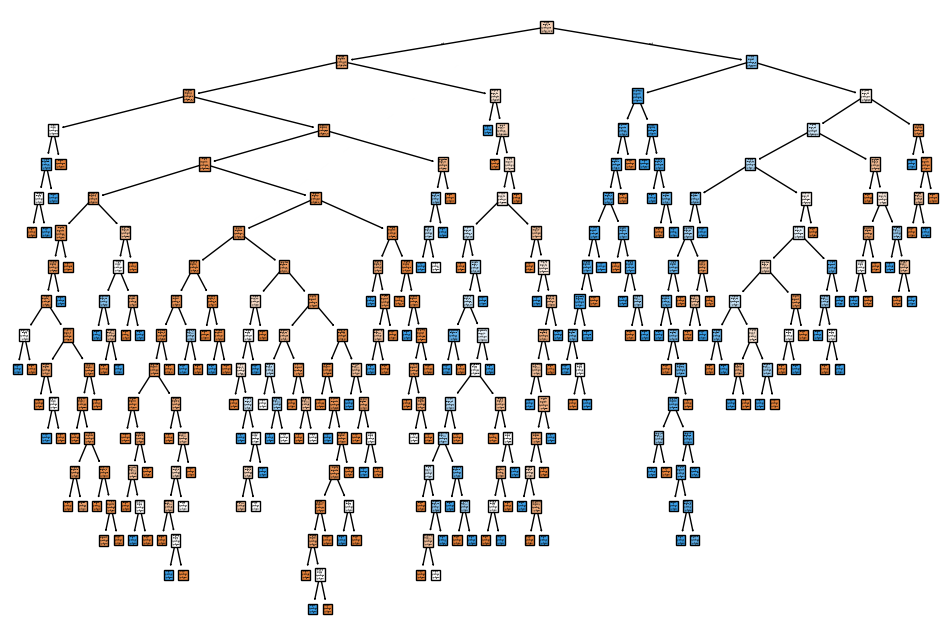

In [225]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold



jopa = data_procced_categories.copy()
# jopa[features_to_scale] = scaler.fit_transform(data[features_to_scale])
train_X = jopa.copy()
train_X = train_X.drop(columns=['Survived', 'Name', 'Ticket', 'Cabin', 'PassengerId'])
train_y = data['Survived']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_train_metric = []
fold_val_metric = []

for train_indices, val_indices in skf.split(train_X, train_y):
    x_train_fold = train_X.iloc[train_indices]
    x_val_fold = train_X.iloc[val_indices]

    y_train_fold = train_y.iloc[train_indices]
    y_val_fold = train_y.iloc[val_indices]
    clf = DecisionTreeClassifier(max_depth=2000, random_state=4322)

    clf.fit(x_train_fold, y_train_fold)

    y_train_pred = clf.predict(x_train_fold)
    y_pred = clf.predict(x_val_fold)

    accuracy_train = accuracy_score(y_train_fold, y_train_pred)
    accuracy = accuracy_score(y_val_fold, y_pred)
    fold_val_metric.append(accuracy)
    fold_train_metric.append(accuracy_train)

print(f"Mean val accuracy: {sum(fold_val_metric) / len(fold_val_metric):.4f}")
print(f"Mean train accuracy: {sum(fold_train_metric) / len(fold_train_metric):.4f}")
print(fold_val_metric)


plt.figure(figsize=(12, 8))


plot_tree(clf, filled=True)
plt.show()
# Mean accuracy:Mean accuracy: 0.7239 - 5 folds
# Mean accuracy: 0.7968 - 10 folds
# Mean accuracy: 0.7284 -  5 folds - 13 neighbors
# Mean accuracy: 0.7441  - 5 folds - weights='distance - 14 neighbors
# Mean accuracy: 0.7620 - 5 folds - weights= 'distance' - 14 neigbors - metic = manhattan

# 0.8092 - w - distance - m - manhattan - n - 14
# 0.8137 - w - uniform - m - manhattan - n - 14 - scaled data
# 

In [206]:
data_procced_categories

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,CabinKnown,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,1,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,0,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,1,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,28.0,1,2,W./C. 6607,23.4500,NaN,0,0,1
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,1,0,0
